## Statistical Inference with Confidence Intervals

Throughout week 2, we have explored the concept of confidence intervals, how to calculate them, interpret them, and what *confidence* really means.  

In this tutorial, we're going to review how to calculate confidence intervals for population proportions and means.

To begin, let's review some of the material from this week and consider once more why confidence intervals are useful tools for deriving insights from data.

First, recall the setting in which nearly all statistical analysis takes place -- the data are a sample from a population, and that population can be described in terms of various numerical parameters.  Using the data, we can estimate a parameter of interest.  For example, suppose that the parameter of interest is the mean credit card debt for all people residing in the United States.  We may call this (unknown) parameter $\theta$.  Using a sample of data, we estimate this parameter, say using the sample mean (average) of the credit card debts for all people in our sample.  We can denote this estimate by $\hat{\theta}$.  We know that $\hat{\theta}$ is not exactly equal to $\theta$, but can we somehow convey which values for $\theta$ could potentially be the actual value?  This is the goal of a confidence interval.

### Why Confidence Intervals?

A confidence interval is a calculated range around a parameter estimate (a statistic) that includes all possible true values of the parameter that are consistent with the data in a certain sense.  For example, in the lecture, we estimated, with 95% confidence, that the population proportion of parents with a toddler that use a car seat for all travel with their toddler was somewhere between 82.2% and 87.7%.  This interval is a random quantity since it is derived from one sample of data.  If we were to obtain a different sample from the same population, we would obtain a different interval.

The key property of a confidence interval is that if we were to repeatedly sample from the population, calculating a confidence interval from each sample, then 95% of our calculated confidence intervals would contain ("cover") the true proportion.

### How are Confidence Intervals Calculated?

A confidence interval for a population proportion can be calculated as follows:

$${\rm Best\ Estimate} \pm {\rm Margin\ of\ Error}$$

Where the *Best Estimate* is the **observed population proportion or mean** and the *Margin of Error* is the **t-multiplier** times the **standard error**.

The t-multiplier is calculated based on the degrees of freedom and desired confidence level.  For samples with more than 30 observations and a confidence level of 95%, we can use the z-multiplier of 1.96 instead of the t-multiplier.  The z-multiplier has the advantage of not depending on any "degrees of freedom".

The equation to create a 95% confidence interval can also be shown as:

$${\rm Population\ Proportion\ or\ Mean} \pm ({\rm t-multiplier} \cdot {\rm Standard\ Error})$$

Lastly, the Standard Error is calculated differenly for the population proportion and mean:

$${\rm Standard\ Error \ for\ Proportion} = \sqrt{\frac{{\rm Population\ Proportion} \cdot (1 - {\rm Population\ Proportion})}{{\rm Number\ Of\ Observations}}}$$

$${\rm Standard\ Error \ for\ Mean} = \frac{{\rm Standard\ Deviation}}{\sqrt{{\rm Number\ Of\ Observations}}}$$

Let's replicate the car seat example from the course lecture:

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

We have a sample of 659 people with a toddler, and 85% of these parents use a car seat all of the time. This point estimate (85%) is not exactly equal to the population proportion of parents who use a car seat.  The standard error (SE) conveys the likely error in the point estimate relative to the population value.  We calculate this standard error next, using the procedure for calculating a standard error of a proportion.

In [ ]:
tstar = 1.96
p = .85
n = 659

se = np.sqrt((p * (1 - p))/n)
se

The standard error is 0.014, or 1.4 percentage points.  Thus, our point estimate (85%) is likely to be around 1.4 percentage points from the truth.

Next we compute a confidence interval for the proportion of parents of toddlers who always use a car seat.  A confidence interval is defined in terms of its "lower confidence bound" (lcb) and "upper confidence bound" (ucb).

In [ ]:
lcb = p - tstar * se
ucb = p + tstar * se
(lcb, ucb)

We don't need to compute the confidence interval from the formula, we can have statsmodels calculate it for us:

In [ ]:
sm.stats.proportion_confint(n * p, n)

Now, let's take our Cartwheel dataset introduced in lecture and calculate a confidence interval for our mean cartwheel distance:

In [ ]:
df = pd.read_csv("/content/Cartwheeldata.csv")

df.head()

In [ ]:
mean = df["CWDistance"].mean()
sd = df["CWDistance"].std()
n = len(df)

n

In [ ]:
tstar = 2.064

se = sd/np.sqrt(n)
se

In [ ]:
lcb = mean - tstar * se
ucb = mean + tstar * se
(lcb, ucb)

In [ ]:
sm.stats.DescrStatsW(df["CWDistance"]).zconfint_mean()

##Confidence Intervals

We will use the 2015-2016 wave of the NHANES data for our analysis.
To illustrate comparison of population proportions, we will analyze the difference between the proportion of females who smoke, and the proportion of males who smoke. The column that specifies smoker and non-smoker is "SMQ020" in our dataset.
To illustrate comparison of population means, we will analyze the difference between mean body mass index (BMI) for females and for males. The column that has the body mass index values is "BMXBMI".
Additionally, the gender is specified in the column "RIAGENDR".

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
da = pd.read_csv("/content/nhanes_2015_2016.csv")

da.SMQ020.head()

##Recoding some variables and inspecting the data

We recode the smoking status variable SMQ020 that is coded 1 (smoker) / 2 (non-smoker) into a new variable SMQ020x that is coded smoke / nosmoke (refused/don't know are coded as missing):

In [ ]:
da["SMQ020x"] = da.SMQ020.replace({1:"smoke", 2:"nonsmoke", 7: np.nan, 9: np.nan})
da["SMQ020x"].value_counts()

In [ ]:
da["RIAGENDRx"] = da.RIAGENDR.replace({1: "Male", 2: "Female"})
da["RIAGENDRx"].value_counts()

In [ ]:
dx = da[["SMQ020x", "RIAGENDRx"]].dropna()
ct = pd.crosstab(dx.RIAGENDRx, dx.SMQ020x)

ct.head()

Next we estimate the conditional rates of smoking in females and in males.

In [ ]:
ct["Total"] = ct["nonsmoke"] + ct["smoke"]
ct["nonsmoke_prop"] = ct["nonsmoke"] / ct["Total"]
ct["smoke_prop"] = ct["smoke"] / ct["Total"]

ct

### Constructing Confidence Intervals


In [ ]:
di = ct.loc["Male", "smoke_prop"] - ct.loc["Female", "smoke_prop"]
di

In [ ]:
# COnstruct the df to run the function
p = .304845
n = 2972
se_female = np.sqrt(p * (1 - p)/n)
se_female
sm.stats.proportion_confint(n * p, n)


In [ ]:
#Suppose we wish to assess the precision of the estimate in the cell above. First, we assess the precision of the female and male smoking rates individually:
pf = ct.loc["Female", "smoke_prop"]
nf = ct.loc["Female", "Total"]

se_female = np.sqrt(pf * (1 - pf) / nf)
se_female

In [ ]:
#Suppose we wish to assess the precision of the estimate in the cell above. First, we assess the precision of the female and male smoking rates individually:
pm = ct.loc["Male", "smoke_prop"]
nm = ct.loc["Male", "Total"]

se_male = np.sqrt(pm * (1 - pm) / nm)
se_male

In [ ]:
se_diff = np.sqrt(se_female**2 + se_male**2)
se_diff

As seen above, the precisions of the female-specific and male-specific smoking rates are quite similar, although the female rate is slightly smaller.

The standard error of the difference between the female and male smoking rates can be obtained by pooling the standard error for females and the standard error for males:

In [ ]:
lcb = di - 1.96 * se_diff
ucb = di + 1.96 * se_diff
(lcb, ucb)

# Difference of Two Population Means
Now we consider estimation of the mean BMI (body mass index) for females and for males, and comparing these means. The NHANES variable containing BMI is BMXBMI. The first few BMI values are as follows:

In [ ]:
ta = da.groupby("RIAGENDRx").agg({"BMXBMI": ["mean", "std", "size"]})
ta

In [ ]:
sns.boxplot(x="RIAGENDRx", y="BMXBMI", data=da);

In [ ]:
# Check the standar error foe male and female according the BMI, where shows that female has a major proportion.
sem_female = ta.loc["Female", ("BMXBMI", "std")] / np.sqrt(ta.loc["Female", ("BMXBMI", "size")])
sem_male = ta.loc["Male", ("BMXBMI", "std")] / np.sqrt(ta.loc["Male", ("BMXBMI", "size")])
(sem_female, sem_male)

In [ ]:
sem_diff = np.sqrt(sem_female**2 + sem_male**2)
sem_diff

In [ ]:
di = ta.loc["Female", ("BMXBMI", "mean")] - ta.loc["Male", ("BMXBMI", "mean")]
di

In [ ]:
lcb = di - 1.96 * sem_diff
ucb = di + 1.96 * sem_diff
(lcb, ucb)

## Confidence intervals case study using NHANES data

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
da = pd.read_csv("/content/nhanes_2015_2016.csv")
da.SMQ020.head()


,SMQ020
0,1
1,1
2,1
3,2
4,2


Confidence intervals for one proportion

We will calculate the proportions of smokers separately for females and for males. Initially we can compare these two proportions and their corresponding confidence intervals informally, but later we will discuss methods to compare two proportions formally using confidence intervals.

First we replace the numeric codes in the variables of interest with text labels, and set the rare answers other than "yes" and "no" to be missing (so they will automatically be omitted from all the analyses below).

In [ ]:
da["SMQ020x"] = da.SMQ020.replace({1: "Yes", 2: "No", 7: np.nan, 9: np.nan})
da["RIAGENDRx"] = da.RIAGENDR.replace({1: "Male", 2: "Female"})


In [ ]:
dx = da[["SMQ020x", "RIAGENDRx"]].dropna()
pd.crosstab(da.SMQ020x, da.RIAGENDRx)

The sample proportion of smokers, and the total sample size for smokers and non-smokers combined. We calculate these values next.

In [ ]:
dz = dx.groupby(dx.RIAGENDRx).agg({"SMQ020x": [lambda x: np.mean(x=="Yes"), np.size]})
dz.columns = ["Proportion", "Total_n"]

dz

Find standar error for male and for female

In [ ]:
#Estimate the standar error for the proportion of female who smoke
p = dz.Proportion.Female
n = dz.Total_n.Female
se_female = np.sqrt(p*(1-p)/n)
print(se_female)

#Estimate the standar error for the proportion of male who smoke
p = dz.Proportion.Male
n = dz.Total_n.Male
se_male = np.sqrt(p*(1-p)/n)
print(se_male)



Next we calculate the 95% confidence intervals for the proportions of female and male smokers using the formula for the one-sample confidence interval for a proportion:

In [ ]:
#Female
p = dz.Proportion.Female
n = dz.Total_n.Female
sm.stats.proportion_confint(n * p, n)

In [ ]:
#Male
p = dz.Proportion.Male
n = dz.Total_n.Male
sm.stats.proportion_confint(n * p, n)

## Confidence intervals comparing two independent proportions

There is no explicit information here about how different the two population proportions might be. To address this question, we can form a confidence interval for the difference between the proportion of females who smoke and the proportion of males who smoke.

The smoking rate is about 20 percentage points higher in men than in women. This difference of around 20 percentage points is only a point estimate of the true value -- it is not exactly equal to the difference between the unknown proportions of females and males who smoke in the population



In [ ]:
# DIference of SE for female and male
se_diff = np.sqrt(se_female**2 + se_male**2)
se_diff

For most purposes, a standard error of 0.013 relative to an observed difference of -0.21 would be considered very small. That is, we have a very accurate estimate of the difference between smoking rates in women and in men.

Now that we have the standard error, we can construct a 95% confidence interval for the difference in proportions by taking the estimate and subtracting and adding two (or 1.96) standard errors from it.

In [ ]:
d = dz.Proportion.Female - dz.Proportion.Male
lcb = d - 2*se_diff
ucb = d + 2*se_diff
print(lcb, ucb)

### Confidence intervals for subpopulations

Since smoking rates vary strongly with age, it might be informative to stratify the data into homogeneous age bands and compare the proportions of female and male smokers within each age band.  We can also calculate the 95% confidence interval for this difference within each age band.

In [ ]:
# Calculate the smoking rates within age/gender groups
da["agegrp"] = pd.cut(da.RIDAGEYR, [18, 30, 40, 50, 60, 70, 80])

pr = da.groupby(["agegrp", "RIAGENDRx"]).agg({"SMQ020x": lambda x: np.mean(x=="Yes")}).unstack()
pr.columns = ["Female", "Male"]

# The number of people for each calculated proportion
dn = da.groupby(["agegrp", "RIAGENDRx"]).agg({"SMQ020x": np.size}).unstack()
dn.columns = ["Female", "Male"]

# Standard errors for each proportion
se = np.sqrt(pr * (1 - pr) / dn)

# Standard error for the difference in female/male smoking rates in every age band
se_diff = np.sqrt(se.Female**2 + se.Male**2)

# Standard errors for the difference in smoking rates between genders, within age bands

# The difference in smoking rates between genders
pq = pr.Female - pr.Male

x = np.arange(pq.size)

In [ ]:
pp = sns.pointplot(x=x, y=pq.values, color='black')
sns.pointplot(x=x, y=pq - 2*se_diff)
sns.pointplot(x=x, y=pq + 2*se_diff)
pp.set_xticklabels(pq.index)
pp.set_xlabel("Age group")
pp.set_ylabel("Female - male smoking proportion")

## Confidence intervals for the mean

In [ ]:
da.groupby("RIAGENDRx").agg({"BMXBMI": "mean"})

In [ ]:
ds = da.groupby("RIAGENDRx").agg({"BMXBMI": ["mean", "std", "size"]})
ds

In [ ]:
sem_female = 7.753 / np.sqrt(2976)
sem_male = 6.253 / np.sqrt(2759)
print(sem_female, sem_male)

In [ ]:
#IF i select only date that i want to check use sm.stats.DescrStatsW(female_bmi).zconfint_mean()
female_bmi = da.loc[da["RIAGENDRx"] == "Female", "BMXBMI"].dropna()

sm.stats.DescrStatsW(female_bmi).zconfint_mean()


In [ ]:
#IF i select only date that i want to check use sm.stats.DescrStatsW(female_bmi).zconfint_mean()
female_bmi = da.loc[da["RIAGENDRx"] == "Male", "BMXBMI"].dropna()

sm.stats.DescrStatsW(female_bmi).zconfint_mean()

### Confidence intervals for the difference between two means

We see that the variance pooling rule gives us a value around 0.19 when comparing the female BMI to the male BMI. This is substantially larger than either the SEM for estimating the female mean (0.14) or the SEM for estimating the male mean (0.12). It is expected that the standard error for the difference between two means is greater than the standard errors for estimating a single mean, since the uncertainty of both gender-specific proportions impacts the statistic.



In [ ]:
sem_diff = np.sqrt(sem_female**2 + sem_male**2)
sem_diff

We can can now construct a 95% confidence interval for the difference between the female and male mean BMI.

This finding indicates that while the point estimate shows that the women in our sample have around 1.1 unit greater BMI than the men in our sample, the true difference between the mean for all women in the population and for all men in the population could fall between 0.79 and 1.53, and still be consistent with the observed data.  We should remember that the true difference could even fall outside of this interval, but this should only happen 1 in 20 times.

In [ ]:
bmi_diff = 29.94 - 28.78
lcb = bmi_diff - 2*sem_diff
ucb = bmi_diff + 2*sem_diff
(lcb, ucb)

###Age-stratified confidence intervals

As a final example, we refine the analysis above by considering the difference of mean BMI values between females and males within age bands. Since age is a quantitative variable, it makes sense to plot these confidence intervals as functions of age. The plot constructed below displays the point estimate of the female/male BMI difference as a black curve, and the lower and upper confidence limits are displayed as blue curves.

In [ ]:
# Calculate the mean, SD, and sample size for BMI within age/gender groups
da["agegrp"] = pd.cut(da.RIDAGEYR, [18, 30, 40, 50, 60, 70, 80])
pr = da.groupby(["agegrp", "RIAGENDRx"]).agg({"BMXBMI": [np.mean, np.std, np.size]}).unstack()

# Calculate the SEM for females and for males within each age band
pr["BMXBMI", "sem", "Female"] = pr["BMXBMI", "std", "Female"] / np.sqrt(pr["BMXBMI", "size", "Female"])
pr["BMXBMI", "sem", "Male"] = pr["BMXBMI", "std", "Male"] / np.sqrt(pr["BMXBMI", "size", "Male"])

# Calculate the mean difference of BMI between females and males within each age band, also  calculate
# its SE and the lower and upper limits of its 95% CI.
pr["BMXBMI", "mean_diff", ""] = pr["BMXBMI", "mean", "Female"] - pr["BMXBMI", "mean", "Male"]
pr["BMXBMI", "sem_diff", ""] = np.sqrt(pr["BMXBMI", "sem", "Female"]**2 + pr["BMXBMI", "sem", "Male"]**2)
pr["BMXBMI", "lcb_diff", ""] = pr["BMXBMI", "mean_diff", ""] - 1.96 * pr["BMXBMI", "sem_diff", ""]
pr["BMXBMI", "ucb_diff", ""] = pr["BMXBMI", "mean_diff", ""] + 1.96 * pr["BMXBMI", "sem_diff", ""]

# Plot the mean difference in black and the confidence limits in blue
x = np.arange(pr.shape[0])
pp = sns.pointplot(x=x, y=pr["BMXBMI", "mean_diff", ""], color='black')
sns.pointplot(x=x, y=pr["BMXBMI", "lcb_diff", ""], color='blue')
sns.pointplot(x=x, y=pr["BMXBMI", "ucb_diff", ""], color='blue')
pp.set_xticklabels(pr.index)
pp.set_xlabel("Age group")
pp.set_ylabel("Female - male BMI difference");

In [ ]:
print(pr)

**Inter-group and intra-group differences:** As the sample size grows, estimates become increasingly precise, but it is important to remember that a highly precise estimate for the mean does not imply that individuals within a population do not vary from each other. To put the differences shown above into greater context, below we show the underlying summaries on which the plot above was based. Note that the standard deviation of BMI within both females and males ranges from around 5 to around 8 depending on the age band. This means, for example, that two randomly-selected males will tend to have BMI values that differ by around 6 units. This is a far greater difference than the mean difference of up to around 1.5 BMI units between females and males. Thus, while there is a tendency for females to have slightly higher BMI than males, the heterogeneity within genders is substantially greater than the difference of means between genders.

### **Confidence intervals and sample size**

A wider confidence interval implies that we have less precision in our estimate. In the simulation below, we calculate the average width of the confidence intervals constructed for each sample size. We see that the confidence interval steadily becomes shorter as the sample size grows. For most settings, the confidence interval will become around half as wide when the sample size is increased by a factor of 4. Below we see this scaling when the sample size increases from 100 to 400, and when it increases from 200 to 800, both of which are increases by a factor of 4.

In [ ]:
dx = da.loc[da.RIAGENDRx=="Female", ["RIAGENDRx", "BMXBMI"]].dropna()

all_cis = []
for n in 100, 200, 400, 800:
    cis = []
    for i in range(500):
        dz = dx.sample(n)
        ci = sm.stats.DescrStatsW(dz.BMXBMI).zconfint_mean()
        cis.append(ci)
    cis = np.asarray(cis)
    mean_width = cis[:, 1].mean() - cis[:, 0].mean()
    print(n, mean_width)
    all_cis.append(cis)

It is also informative to plot the individual confidence intervals, computed for 500 subsamples of size 100, to see how they vary. The vertical grey bars below each correspond to a confidence interval. The red horizontal line is the mean BMI calculated using the entire data set, which can be taken as a proxy for othe population mean. While the individual intervals are quite different from each other, it appears that the vast majority of them cover the population value.

In [ ]:
ci = all_cis[0]
for j, x in enumerate(ci):
    plt.plot([j, j], x, color='grey')
    plt.gca().set_ylabel("BMI")
mn = dx.BMXBMI.mean()
plt.plot([0, 500], [mn, mn], color='red')

We can calculate the fraction of the 500 simulated confidence intervals that did not cover the target value. This is called the "non-coverage probability". There are two ways for an interval to fail to cover the target -- either the upper limit of the interval can fall below the target, or the lower limit of the interval can fall above the target. We calculate each of these below. The sum of these two probabilities should be around 0.05, which is the allowed proportion of the time that a 95% confidence interval does not cover its target.

In [ ]:
print(np.mean(ci[:, 1] < mn)) # Upper limit falls below the target
print(np.mean(ci[:, 0] > mn)) # Lower limit falls above the target

# Practice notebook for confidence intervals using NHANES data


In [ ]:
da = pd.read_csv("/content/nhanes_2015_2016.csv")

NameError: name 'pd' is not defined

In [ ]:
da["DMDEDUC2"].unique()

## Question 1

Restrict the sample to women between 35 and 50, then use the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to partition this sample into two groups - women who are currently married, and women who are not currently married.  Within each of these groups, calculate the proportion of women who have completed college.  Calculate 95% confidence intervals for each of these proportions.

In [ ]:
#Classify by gender
da["RIAGENDR_gender"] = da.RIAGENDR.replace({1: "Male", 2: "Female"})
da["RIAGENDR_gender"].unique()

In [ ]:
#Classify by Complete collgege
da = da[(da["DMDEDUC2"] != 9) & (~da["DMDEDUC2"].isna())]
da["DMDEDUC2_collegue"] = da.DMDEDUC2.replace({5: "Completed", 3: "No_Completed", 4:"No_Completed", 2:"No_Completed", 1:"No_Completed"}).dropna()
da["DMDEDUC2_collegue"].unique()


In [ ]:
#Classify by marrige
da["DMDMARTL_label"] = da["DMDMARTL"].replace({1: "Married",2: "NoMarried",3: "NoMarried",4: "NoMarried",5: "NoMarried",6: "NoMarried",77: np.nan,99: np.nan})
da.dropna()
da = da[(~da["DMDMARTL_label"].isna())]
da["DMDMARTL_label"].unique()


In [ ]:
women_35_50 = da[(da["RIAGENDR_gender"] == "Female") & (da["RIDAGEYR"].between(35, 50)) & (da["DMDMARTL_label"].isin(["Married", "NoMarried"]))]

women_35_50 = da[["RIAGENDR_gender", "RIDAGEYR", "DMDMARTL_label", "DMDEDUC2_collegue"]]


In [ ]:
#Calculate proportion

dx = women_35_50.dropna()
ct = pd.crosstab(dx.DMDMARTL_label, dx.DMDEDUC2_collegue)

ct

In [ ]:
#Create the percentage

ct["Total"] = ct["Completed"] + ct["No_Completed"]
ct["completed_prop"] = ct["Completed"] / ct["Total"]
ct["no_completed_prop"] = ct["No_Completed"] / ct["Total"]


In [ ]:
ct

In [ ]:
# Female Married and completed collegue
p = ct.loc['Married', 'completed_prop']
n = ct.loc['Married', 'Completed']
sm.stats.proportion_confint(n_married * p_married, n_married)


In [ ]:

# Female Not Married and completed collegue
p_nomarried = ct.loc['NoMarried', 'completed_prop']
n_nomarried = ct.loc['NoMarried', 'Completed']
sm.stats.proportion_confint(n_nomarried * p_nomarried, n_nomarried)


## Question 2

Construct a 95% confidence interval for the proportion of smokers who are female. Construct a 95% confidence interval for the proportion of smokers who are male. Construct a 95% confidence interval for the **difference** between those two gender proportions.

In [ ]:
# Female and Male
# Diference
da = pd.read_csv("/content/nhanes_2015_2016.csv")

In [ ]:
#Classify by gender
da["RIAGENDR_gender"] = da.RIAGENDR.replace({1: "Male", 2: "Female"})
da["SMQ020x"] = da.SMQ020.replace({1:"smoke", 2:"nonsmoke", 7: np.nan, 9: np.nan})


da["SMQ020x"].unique()

array(['smoke', 'nonsmoke', nan], dtype=object)

In [ ]:
#Filder DF to create table
dx = da[["RIAGENDR_gender", "SMQ020x"]].dropna()
ct = pd.crosstab(dx.RIAGENDR_gender, dx.SMQ020x)

ct

SMQ020x,nonsmoke,smoke
RIAGENDR_gender,,
Female,2066,906
Male,1340,1413


In [ ]:
#Add new data
#Create the percentage

ct["Total"] = ct["smoke"] + ct["nonsmoke"]
ct["smoke_prop"] = ct["smoke"]/ct["Total"]
ct


SMQ020x,nonsmoke,smoke,Total,smoke_prop
RIAGENDR_gender,,,,
Female,2066,906,2972,0.304845
Male,1340,1413,2753,0.513258


In [ ]:
#Crerate the confidence interval
# Female Smoke
p = ct.loc['Female', 'smoke_prop']
n = ct.loc['Female', 'smoke']

seFemale = sm.stats.proportion_confint(n * p, n)

In [ ]:
# Male Smoke
#Crerate the confidence interval
p = ct.loc['Male', 'smoke_prop']
n = ct.loc['Male', 'smoke']

seMale = sm.stats.proportion_confint(n * p, n)

In [ ]:
# Calculate individual standard errors for proportions
p_female = ct.loc['Female', 'smoke_prop']
n_female = ct.loc['Female', 'Total']
se_female = np.sqrt(p_female * (1 - p_female) / n_female)

p_male = ct.loc['Male', 'smoke_prop']
n_male = ct.loc['Male', 'Total']
se_male = np.sqrt(p_male * (1 - p_male) / n_male)

# Calculate the standard error of the difference between the two proportions
se_diff = np.sqrt(se_female**2 + se_male**2)
se_diff

np.float64(0.012729881381407434)

Construct a 95% interval for height (BMXHT) in centimeters. Then convert height from centimeters to inches by dividing by 2.54, and construct a 95% confidence interval for height in inches. Finally, convert the endpoints (the lower and upper confidence limits) of the confidence interval from inches to back to centimeters

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [ ]:
height_cm = da["BMXHT"].dropna()

In [ ]:
#Define a function to call the process multiple times
def get_95_ci(data):
    """Calculates a 95% confidence interval for the mean."""
    mean = np.mean(data)
    std_err = stats.sem(data)  # Standard error of the mean
    # stats.t.interval uses the sample size (df) to find the correct multiplier
    ci = stats.t.interval(0.95, len(data) - 1, loc=mean, scale=std_err)
    return ci

In [ ]:
# --- Task 1: 95% CI for height in centimeters ---
ci_cm = get_95_ci(height_cm)
print(f"95% CI (cm): {ci_cm}")

95% CI (cm): (np.float64(165.88049527760143), np.float64(166.40517368062177))


In [ ]:
# Conversion: centimeters / 2.54 = inches
height_in = height_cm / 2.54
ci_in = get_95_ci(height_in)
print(f"95% CI (inches): {ci_in}")

95% CI (inches): (np.float64(65.30728160535489), np.float64(65.51384790575659))


In [ ]:
# --- Task 3: Convert CI endpoints from inches back to centimeters ---
# Conversion: inches * 2.54 = centimeters
ci_back_to_cm = (ci_in[0] * 2.54, ci_in[1] * 2.54)
print(f"Converted CI (back to cm): {ci_back_to_cm}")

Converted CI (back to cm): (np.float64(165.88049527760143), np.float64(166.40517368062174))


Partition the sample based on 10-year age bands, i.e. the resulting groups will consist of people with ages from 18-28, 29-38, etc. Construct 95% confidence intervals for the difference between the mean BMI for females and for males within each age band.

In [ ]:
da["RIAGENDR_gender"] = da.RIAGENDR.replace({1: "Male", 2: "Female"})

# Partition the sample based on 10-year age bands
da["agegrp"] = pd.cut(da.RIDAGEYR, bins=[18, 28, 38, 48, 58, 68, 78, 89], right=True)

# Calculate the mean, SD, and sample size for BMI within age/gender groups
# Drop rows where BMI or agegrp is missing
df_bmi_age = da[["BMXBMI", "RIAGENDR_gender", "agegrp"]].dropna()

pr = df_bmi_age.groupby(["agegrp", "RIAGENDR_gender"]).agg(
    mean_bmi=("BMXBMI", "mean"),
    std_bmi=("BMXBMI", "std"),
    size_bmi=("BMXBMI", "size")
).unstack()

# Flatten the multi-index columns for easier access
pr.columns = ['_'.join(col).strip() for col in pr.columns.values]

pr["Total"] = pr["size_bmi_Female"] + pr["size_bmi_Male"]

pr

/tmp/ipykernel_3067/1978975305.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pr = df_bmi_age.groupby(["agegrp", "RIAGENDR_gender"]).agg(


,mean_bmi_Female,mean_bmi_Male,std_bmi_Female,std_bmi_Male,size_bmi_Female,size_bmi_Male,Total
agegrp,,,,,,,
"(18, 28]",28.019433,27.058186,8.048854,6.679515,494,452,946
"(28, 38]",29.943443,29.697180,7.959097,6.726690,488,461,949
"(38, 48]",31.003733,29.514646,8.044642,6.104950,509,396,905
"(48, 58]",30.787361,29.385132,7.647590,6.151534,451,417,868
"(58, 68]",31.054664,29.232462,7.779502,5.959024,461,459,920
"(68, 78]",30.537818,28.720270,6.780588,5.336652,275,296,571
"(78, 89]",27.850000,27.464368,5.483781,4.695650,198,174,372


In [ ]:
# Calculate the SEM for females and for males within each age band
pr["sem_bmi_Female"] = pr["std_bmi_Female"] / np.sqrt(pr["size_bmi_Female"])
pr["sem_bmi_Male"] = pr["std_bmi_Male"] / np.sqrt(pr["size_bmi_Male"])

# Calculate the mean difference of BMI between females and males within each age band
pr["mean_diff_bmi"] = pr["mean_bmi_Female"] - pr["mean_bmi_Male"]

# Calculate the standard error of the difference in BMI between genders within each age band
pr["sem_diff_bmi"] = np.sqrt(pr["sem_bmi_Female"]**2 + pr["sem_bmi_Male"]**2)

# Calculate the lower and upper limits of the 95% CI for the difference
pr["lcb_diff_bmi"] = pr["mean_diff_bmi"] - 1.96 * pr["sem_diff_bmi"]
pr["ucb_diff_bmi"] = pr["mean_diff_bmi"] + 1.96 * pr["sem_diff_bmi"]

# Display the results, focusing on the relevant columns
display(pr[['mean_bmi_Female', 'mean_bmi_Male', 'mean_diff_bmi', 'sem_diff_bmi', 'lcb_diff_bmi', 'ucb_diff_bmi']])

,mean_bmi_Female,mean_bmi_Male,mean_diff_bmi,sem_diff_bmi,lcb_diff_bmi,ucb_diff_bmi
agegrp,,,,,,
"(18, 28]",28.019433,27.058186,0.961247,0.479426,0.021572,1.900923
"(28, 38]",29.943443,29.697180,0.246263,0.477454,-0.689548,1.182073
"(38, 48]",31.003733,29.514646,1.489086,0.470384,0.567134,2.411039
"(48, 58]",30.787361,29.385132,1.402230,0.469496,0.482017,2.322442
"(58, 68]",31.054664,29.232462,1.822202,0.456777,0.926919,2.717484
"(68, 78]",30.537818,28.720270,1.817548,0.513228,0.811622,2.823474
"(78, 89]",27.850000,27.464368,0.385632,0.527823,-0.648901,1.420165


/tmp/ipykernel_3067/2738290157.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  pp.set_xticklabels([f'{interval.left}-{interval.right}' for interval in pr.index.get_level_values('agegrp')])


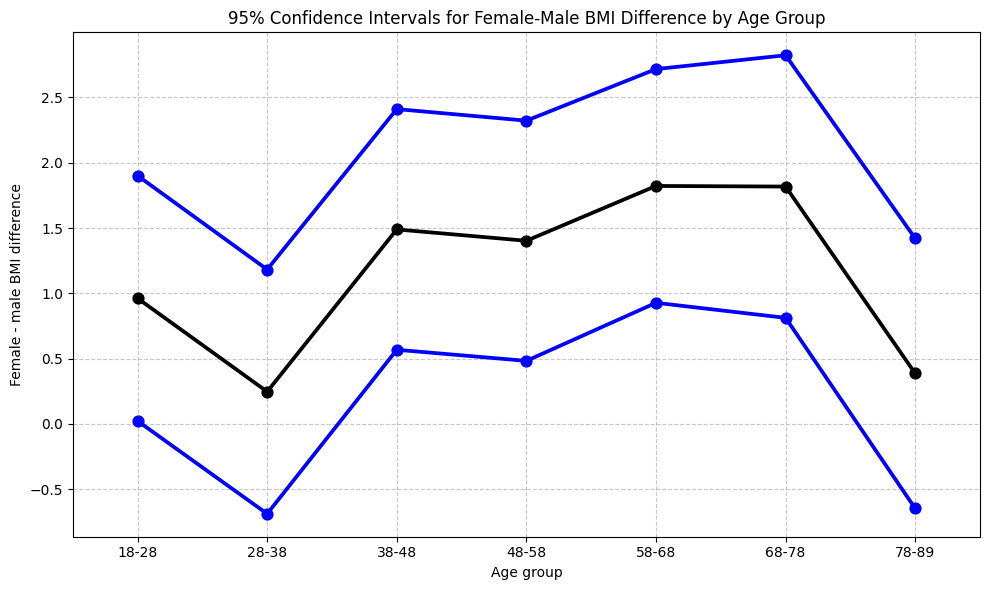

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a numeric index for plotting
x = np.arange(pr.shape[0])

plt.figure(figsize=(10, 6))
# Plot the mean difference in black
pp = sns.pointplot(x=x, y=pr["mean_diff_bmi"], color='black')
# Plot the lower confidence bound in blue
sns.pointplot(x=x, y=pr["lcb_diff_bmi"], color='blue')
# Plot the upper confidence bound in blue
sns.pointplot(x=x, y=pr["ucb_diff_bmi"], color='blue')

# Set x-axis labels to age groups
pp.set_xticklabels([f'{interval.left}-{interval.right}' for interval in pr.index.get_level_values('agegrp')])

pp.set_xlabel("Age group")
pp.set_ylabel("Female - male BMI difference")
pp.set_title("95% Confidence Intervals for Female-Male BMI Difference by Age Group")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Creating confidence intervals in python
In this assessment, you will look at data from a study on toddler sleep habits.

The confidence intervals you create and the questions you answer in this Jupyter notebook will be used to answer questions in the following graded assignment.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import t
pd.set_option('display.max_columns', 30) # set so can see all columns of the DataFrame

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/UMstatspy/UMStatsPy/master/Course_2/nap_no_nap.csv")

In [ ]:
df.columns

Index(['id', 'sex', 'age (months)', 'dlmo time', 'days napped', 'napping',
       'nap lights outl time', 'nap sleep onset', 'nap midsleep',
       'nap sleep offset', 'nap wake time', 'nap duration', 'nap time in bed',
       'night bedtime', 'night sleep onset', 'sleep onset latency',
       'night midsleep time', 'night wake time', 'night sleep duration',
       'night time in bed', '24 h sleep duration', 'bedtime phase difference',
       'sleep onset phase difference', 'midsleep phase difference',
       'wake time phase difference'],
      dtype='object')

In [ ]:
df.napping.unique()



array([0, 1])

In [ ]:
n = df.size
n

500

In [ ]:
df["nappingx"] = df.napping.replace({1: "Nap", 0: "NoNap"})


In [ ]:
# How many registers has df with 'Nap' in 'nappingx'
a = (df['nappingx'] == 'NoNap').sum()
print(f"Number of registers with 'NoNap': {a}")

Number of registers with 'NoNap': 5


In [ ]:
# Convert 'night bedtime' into decimalized time
df.loc[:,'night bedtime'] = np.floor(df['night bedtime'])*60 + np.round(df['night bedtime']%1,2 )*100

Now, isolate the column 'night bedtime' for those who nap into a new variable, and those who didn't nap into another new variable.

In [ ]:
bedtime_nap = df.loc[df['nappingx'] == 'Nap', 'night bedtime']
bedtime_no_nap = df.loc[df['nappingx'] == 'NoNap', 'night bedtime']

In [ ]:
# Now find the sample mean bedtime for nap and no_nap.
nap_mean_bedtime = bedtime_nap.mean()
nap_mean_bedtime_no_nap = bedtime_no_nap.mean()

In [ ]:
print("Bedtime for Nappers:")
display(bedtime_nap.describe())

print("\nBedtime for Non-Nappers:")
display(bedtime_no_nap.describe())

Bedtime for Nappers:


,night bedtime
count,15.000000
mean,1233.066667
std,34.445540
min,1185.000000
25%,1218.000000
50%,1226.000000
75%,1244.500000
max,1321.000000



Bedtime for Non-Nappers:


,night bedtime
count,5.000000
mean,1191.000000
std,34.300146
min,1161.000000
25%,1163.000000
50%,1186.000000
75%,1200.000000
max,1245.000000


Question: Given our sample sizes of  𝑛1  and  𝑛2  for napping and non napping toddlers respectively, how many degrees of freedom ( 𝑑𝑓 ) are there for the associated  𝑡  distributions?

In [ ]:
from scipy.stats import t

n_nap = len(bedtime_nap)
n_no_nap = len(bedtime_no_nap)

df_nap = n_nap - 1
df_no_nap = n_no_nap - 1

print(f"Degrees of freedom for napping group: {df_nap}")
print(f"Degrees of freedom for non-napping group: {df_no_nap}")

Degrees of freedom for napping group: 14
Degrees of freedom for non-napping group: 4


In [ ]:
# Now to create our confidence intervals. For the average bedtime for nap and no nap, find the upper and lower bounds for the respective confidence intervals.

nap_se_mean_bedtime = bedtime_nap.std() / np.sqrt(n_nap)
no_nap_se_mean_bedtime = bedtime_no_nap.std() / np.sqrt(n_no_nap)

In [ ]:
# Calculate t-star for 95% confidence interval for each group
t_star_nap = t.ppf(0.975, df_nap)
t_star_no_nap = t.ppf(0.975, df_no_nap)

# Calculate confidence interval for napping group
lcb_nap = nap_mean_bedtime - t_star_nap * nap_se_mean_bedtime
ucb_nap = nap_mean_bedtime + t_star_nap * nap_se_mean_bedtime

# Calculate confidence interval for non-napping group
lcb_no_nap = nap_mean_bedtime_no_nap - t_star_no_nap * no_nap_se_mean_bedtime
ucb_no_nap = nap_mean_bedtime_no_nap + t_star_no_nap * no_nap_se_mean_bedtime

print(f"t Napping Group: ({t_star_nap})")
print(f"t for Non-Napping Group: ({t_star_no_nap})")

print(f"95% Confidence Interval for Napping Group: ({lcb_nap:.2f}, {ucb_nap:.2f})")
print(f"95% Confidence Interval for Non-Napping Group: ({lcb_no_nap:.2f}, {ucb_no_nap:.2f})")

t Napping Group: (2.1447866879169273)
t for Non-Napping Group: (2.7764451051977987)
95% Confidence Interval for Napping Group: (1213.99, 1252.14)
95% Confidence Interval for Non-Napping Group: (1148.41, 1233.59)


In [ ]:
# Calculate t-star for 95% confidence interval for each group
t_star_nap = t.ppf(0.975, df_nap)
t_star_no_nap = t.ppf(0.975, df_no_nap)

# Calculate confidence interval for napping group
lcb_nap = nap_mean_bedtime - t_star_nap * nap_se_mean_bedtime
ucb_nap = nap_mean_bedtime + t_star_nap * nap_se_mean_bedtime

# Calculate confidence interval for non-napping group
lcb_no_nap = nap_mean_bedtime_no_nap - t_star_no_nap * no_nap_se_mean_bedtime
ucb_no_nap = nap_mean_bedtime_no_nap + t_star_no_nap * no_nap_se_mean_bedtime

print(f"t Napping Group: ({t_star_nap})")
print(f"t for Non-Napping Group: ({t_star_no_nap})")

print(f"95% Confidence Interval for Napping Group: ({lcb_nap:.2f}, {ucb_nap:.2f})")
print(f"95% Confidence Interval for Non-Napping Group: ({lcb_no_nap:.2f}, {ucb_no_nap:.2f})")

t Napping Group: (2.1447866879169273)
t for Non-Napping Group: (2.7764451051977987)
95% Confidence Interval for Napping Group: (1213.99, 1252.14)
95% Confidence Interval for Non-Napping Group: (1148.41, 1233.59)
